In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import adjusted_rand_score

# Module 3 Assignment:

This week, you learned about several graph generation models. In this assignment, you will gain experience utilizing these models with the python networkx library.

# Part 1: The Erdos Renyi model


# Task 1a:
 Recall that the Erdos-Renyi model is made to generate a graph where every edge exists with probability p. Find the minimum value of p such that a graph with n=50 nodes has at least 100 edges. p should be an integer between 1 and 100. You will turn it into a float between 1 and 0 by dividing it by 100 when inputting the 'p' argument for graph generation. 

The function should return the value of p as an integer. For example, if 20/100 resulted in at least 100 edges, you would return '20' as an integer. You will assign `num_edges` to the resulting number of edges generated in the simulated graph. You will return `p` and `num_edges` in a tuple in the given format.

Use seed = 42 when generating the graph.


In [2]:
task_id = '1a'


In [3]:
def task_1a_solution():
    n = 50
    seed = 42

    for p_int in range(1, 101):  # p from 1 to 100 inclusive
        p = p_int / 100
        G = nx.erdos_renyi_graph(n=n, p=p, seed=seed)
        num_edges = G.number_of_edges()
        
        if num_edges >= 100:
            return num_edges, p_int  # return integer p, not float


In [4]:
# Use this cell to explore your solution.

task_1a_solution()

(101, 9)

In [5]:
print(f"Task {task_id} - AG tests")
stu_ans = task_1a_solution()

print(f"Task {task_id} - your answer:\n{stu_ans}")

assert isinstance(
    stu_ans, tuple
), f"Task {task_id}: Your function should return an tuple. "

assert isinstance(
    stu_ans[0], int
), f"Task {task_id}: The first element of the tuple should represent the number of edges as an integer. "

assert isinstance(
    stu_ans[1], int
), f"Task {task_id}: The second element of the tuple should represent a value of p between 1 and 100. "


Task 1a - AG tests
Task 1a - your answer:
(101, 9)


# Task 1b:

We also learned the equation to calculate the expected number of edges when creating a graph with the Erdos-Renyi model:

$$
E = p \cdot \frac{n(n-1)}{2}
$$

Find the expected number of edges. Your function should return the difference between the simulated number of edges you obtained in 1a, and the predicted number of edges given the p you found in task_1a() along with n=100 nodes. The order of operations is given; Do not change it.

In [6]:
task_id = '1b'


In [7]:
def task_1b_solution():
    simulated_edges, p = task_1a_solution()  # p is an integer 1–100
    n = 100
    p_float = p / 100

    predicted_edges = p_float * (n * (n - 1) / 2)

    return predicted_edges - simulated_edges

In [8]:
# Use this cell to explore your solution.

task_1b_solution()

344.5

In [9]:
print(f"Task {task_id} - AG tests")
stu_ans = task_1b_solution()

print(f"Task {task_id} - your answer:\n{stu_ans}")

assert isinstance(
    stu_ans, float
), f"Task {task_id}: Your function should return a float. "



Task 1b - AG tests
Task 1b - your answer:
344.5


# Task 1c:

This task is similar to task 1a. Find p to where when we have p/100 as the p value when generating the Erdos-Renyi graph, at least 60% of nodes are in a connected component when simulating the generation of an Erdos-Renyi graph with 100 nodes.

Use seed = 42 when generating your network.

The function should return p, with p being a value between 1 and 100, and largest_cc_size, being an integer representing the size of the largest connected component. 

Hint(s):
- You may find the python built-in `max()` and `nx.connected_components()` functions helpful.


In [10]:
task_id = '1c'


In [11]:
def task_1c_solution():
    num_nodes = 100  
    target = 60
    seed = 42

    for p in range(1, 101):  # Start from 1 to avoid p=0
        p_value = p / 100
        G = nx.erdos_renyi_graph(n=num_nodes, p=p_value, seed=seed)
        connected_components = nx.connected_components(G)
        largest_cc_size = max(len(component) for component in connected_components)

        if largest_cc_size >= target:
            return p, largest_cc_size

In [12]:
# Use this cell to explore your solution.

task_1c_solution()

(2, 73)

In [13]:
print(f"Task {task_id} - AG tests")
stu_ans = task_1c_solution()

print(f"Task {task_id} - your answer:\n{stu_ans}")

assert isinstance(
    stu_ans, tuple
), f"Task {task_id}: Your function should return a tuple."

assert isinstance(
    stu_ans[0], int
), f"Task {task_id}: The first element of the tuple should be p, an integer between 0 and 99."

assert isinstance(
    stu_ans[1], int
), f"Task {task_id}: The first element of the tuple should be largest_cc_size, an integer."



Task 1c - AG tests
Task 1c - your answer:
(2, 73)


# Part 2: Stochastic block model

# Task 2a:

Use networkx's stochastic block model function with a seed of 42 to generate a graph that has two communities of size n with p_intra probability of intra-community edges, and p_inter probability of inter-community edges. The function below should return the resulting graph. Refer to the tutorial for an example of how to accomplish this. 

In [14]:
task_id = '2a'


In [15]:
def task_2a_solution(n: int, p_intra: float, p_inter: float):
    sizes = [n, n]
    p_matrix = [
        [p_intra, p_inter],
        [p_inter, p_intra]
    ]
    
    G = nx.stochastic_block_model(sizes, p_matrix, seed=42)
    
    return G

In [16]:
# Use this cell to explore your solution.

task_2a_solution(n = 10, p_inter = 0.5, p_intra = 0.4)

In [17]:
print(f"Task {task_id} - AG tests")
stu_ans = task_2a_solution(n = 10, p_inter = 0.5, p_intra = 0.4)

print(f"Task {task_id} - your answer:\n{stu_ans}")

assert isinstance(
    stu_ans, nx.classes.graph.Graph
), f"Task {task_id}: Your function should return a graph of type nx.classes.graph.Graph. "




Task 2a - AG tests
Task 2a - your answer:
Graph named 'stochastic_block_model' with 20 nodes and 87 edges


# Task 2b:

This task will involve bringing back community detection algorithms from a previous assignment to detect communities we've created using the Stochastic Block model, and returning the adjusted rand index score of the top-performing algorithm. 

To start you off, we've created a graph with the probabilities of 0.5 and 0.4 for the formation of inter-community and intra-community edges, respectively. 

You will now need to detect communities using the networkX greedy, fluid communities, or label propogation algorithms. Use the communities you obtain from their community detection functions as arguments to the `find_node_communities` function we've defined for you. 

The return of the `find_node_communities` alters the community assignment object you obtained with the community detection algorithm function to a format where we can compare it to `reference_labels`.

The metric we will use to compare the communities detected by the algorithms and `reference_labels` is called Adjusted Rand Index (ARI), a commonly used statistical measure which quantifies the similarity between two partitions of a dataset. Higher values indicate a strong similarity in clusterings. 

To obtain the score, call `adjusted_rand_score(reference_labels, detected_labels)`. `detected_labels` should be the list returned by the `find_nodes_communities` function.


Note: `p_inter` is passed in as an argument so we can use your code for a later question. Do not change this.


In [18]:
task_id = '2b'


#This function takes in the communities you generated with the nx.**.communities function and returns a list representing the communities assigned to each
# Node. 

#     Com. 1 Com. 2
#Ex. [{0,1},{2,3}] turns into [0,0,1,1]
def find_node_communities(num_nodes, communities):
    #The list where each node will have an entry, where the value is it's community.
    detected_communities = [-1] * num_nodes
    for community_num, community_of_nodes in enumerate(communities):
        for node in community_of_nodes:
            detected_communities[node] = community_num

    return detected_communities



In [19]:
import networkx as nx
from sklearn.metrics import adjusted_rand_score

def task_2b_solution(p_inter = 0.4):
    G = task_2a_solution(n=50, p_intra=0.5, p_inter=p_inter)
    reference_labels = [0] * 50 + [1] * 50  # True communities: [0,...,0,1,...,1]
    num_nodes = 100

    best_ari = -1  # Initialize with a low value

    # Try Greedy Modularity
    try:
        communities = nx.algorithms.community.greedy_modularity_communities(G)
        detected_labels = find_node_communities(num_nodes, communities)
        ari = adjusted_rand_score(reference_labels, detected_labels)
        best_ari = max(best_ari, ari)
    except Exception as e:
        pass

    # Try Label Propagation
    try:
        communities = nx.algorithms.community.label_propagation_communities(G)
        detected_labels = find_node_communities(num_nodes, communities)
        ari = adjusted_rand_score(reference_labels, detected_labels)
        best_ari = max(best_ari, ari)
    except Exception as e:
        pass

    # Try Fluid Communities (if the graph is connected)
    try:
        if nx.is_connected(G):
            communities = nx.algorithms.community.asyn_fluidc(G, k=2, seed=42)
            detected_labels = find_node_communities(num_nodes, communities)
            ari = adjusted_rand_score(reference_labels, detected_labels)
            best_ari = max(best_ari, ari)
    except Exception as e:
        pass

    return best_ari




In [20]:
task_2b_solution(p_inter = 0.4)

0.0878132169688245

In [21]:
print(f"Task {task_id} - AG tests")
stu_ans = task_2b_solution(p_inter = 0.45)

print(f"Task {task_id} - your answer:\n{stu_ans}")

assert isinstance(
    stu_ans, float
), f"Task {task_id}: Your function should return a float. "



Task 2b - AG tests
Task 2b - your answer:
0.010352432821713102


# Task 2c:

Let's see how adjusting p_intra changes ARI! Write a function returning the ari values where p_intra is 1 to 10, inclusive, out of 10 (0.1, 0.2, 0.3, ... 1.0). Using your task_2b solution is heavily encouraged.

In [22]:
task_id = '2c'


In [23]:
def task_2c_solution():
    ari_vals = []

    for i in range(1, 11):  # i from 1 to 10
        p_intra = i / 10.0
        G = task_2a_solution(n=50, p_intra=p_intra, p_inter=0.4)
        reference_labels = [0] * 50 + [1] * 50
        num_nodes = 100
        best_ari = -1

        # Greedy Modularity
        try:
            communities = nx.algorithms.community.greedy_modularity_communities(G)
            detected_labels = find_node_communities(num_nodes, communities)
            ari = adjusted_rand_score(reference_labels, detected_labels)
            best_ari = max(best_ari, ari)
        except:
            pass

        # Label Propagation
        try:
            communities = nx.algorithms.community.label_propagation_communities(G)
            detected_labels = find_node_communities(num_nodes, communities)
            ari = adjusted_rand_score(reference_labels, detected_labels)
            best_ari = max(best_ari, ari)
        except:
            pass

        # Fluid Communities (only if connected)
        try:
            if nx.is_connected(G):
                communities = nx.algorithms.community.asyn_fluidc(G, k=2, seed=42)
                detected_labels = find_node_communities(num_nodes, communities)
                ari = adjusted_rand_score(reference_labels, detected_labels)
                best_ari = max(best_ari, ari)
        except:
            pass

        ari_vals.append(best_ari)

    return ari_vals


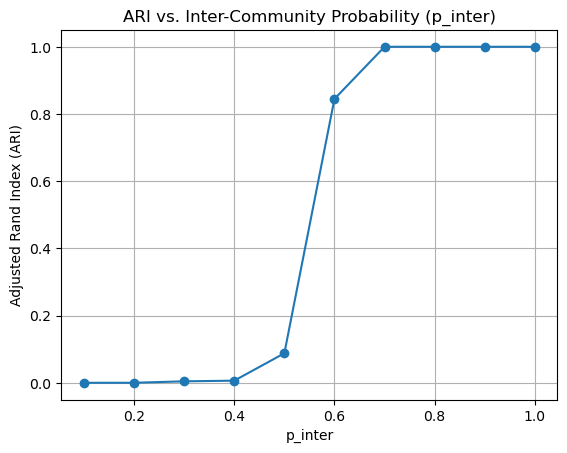

In [24]:
# Use this cell to explore your solution.

# Plot the ARI values
plt.plot([p/10 for p in range(1, 11)], task_2c_solution(), marker='o')
plt.xlabel('p_inter')
plt.ylabel('Adjusted Rand Index (ARI)')
plt.title('ARI vs. Inter-Community Probability (p_inter)')
plt.grid(True)

# Show the plot
plt.show()

In [25]:
print(f"Task {task_id} - AG tests")
stu_ans = task_2c_solution()

print(f"Task {task_id} - your answer:\n{stu_ans}")

assert isinstance(
    stu_ans, list
), f"Task {task_id}: Your function should return a list. "

assert (
    len(stu_ans) == 10
), f"Task {task_id}: Your returned ndarray has an incorrect number of elements. "

assert all(
    isinstance(num, float) for num in stu_ans
), (
    f"Task {task_id}: Your returned list should be a list of floats "
)



Task 2c - AG tests
Task 2c - your answer:
[0.0, 0.0, 0.004342857142857143, 0.0062658951015443585, 0.0878132169688245, 0.8448326530612245, 1.0, 1.0, 1.0, 1.0]


# Part 3: Configuration graph generation model

# Task 3a:
Zark Muckerberg just created a new social media network. There are 6 users on it. One with 4 friends, one with 3 friends, three with 2 friends, and one with 1 friend. Use the configuration graph generation model to create a graph that could represent this network with seed=42.

In [26]:
task_id = '3a'


In [27]:
def task_3a_solution():
    degree_sequence = [4, 3, 2, 2, 2, 1]
    G = nx.configuration_model(degree_sequence, seed=42)
    
    return G


In [28]:
# Use this cell to explore your solution.

task_3a_solution()

In [29]:
print(f"Task {task_id} - AG tests")
stu_ans = task_3a_solution()

print(f"Task {task_id} - your answer:\n{stu_ans}")

assert isinstance(
    stu_ans, nx.classes.graph.Graph
), f"Task {task_id}: Your function should return a graph of type nx.classes.graph.Graph. "




Task 3a - AG tests
Task 3a - your answer:
MultiGraph with 6 nodes and 7 edges


# Task 3b:

We are going to use the football game network for this question. Calculate the degree distribution of the network, and use the nx configuration model to create a new graph from that degree distribution with seed=42. The function below should return the new graph. 

Hint: You may find the `.degree()` function useful.

In [30]:
task_id = '3b'

import networkx as nx
import pandas as pd
from collections import Counter

G_football = nx.read_gml('assets/football.gml', label='id')



In [31]:
def task_3b_solution():
    degree_sequence = [deg for node, deg in G_football.degree()]
    new_G = nx.configuration_model(degree_sequence, seed=42)
    return new_G


In [32]:
# Use this cell to explore your solution.

task_3b_solution()

In [33]:
print(f"Task {task_id} - AG tests")
stu_ans = task_3b_solution()

print(f"Task {task_id} - your answer:\n{stu_ans}")

assert isinstance(
    stu_ans, nx.classes.multigraph.MultiGraph
), f"Task {task_id}: Your function should return an np.ndarray. "




Task 3b - AG tests
Task 3b - your answer:
MultiGraph with 115 nodes and 613 edges


# Task 3c (Ungraded):

In this question, we're going to compare the real-world network with the network you created based on the real-world network's degree distribution in the previous question. We're going to examine the following metrics:
```m
[
    "Clustering Coefficient",
    "Average Shortest Path Length",
    "Assortativity",
    "Density",
    "Number of Connected Components" ,
    "Average Degree",
    "Diameter",
    "Fraction of Nodes in Largest CC",
]
```

Which do you think will have changed? 

Return the names of the Metrics that you believe will have remained similar as a list of strings.



In [34]:
def task_3c():
    sol = [
        "Density",
        "Average Degree"
    ]
    
    return sol


Now take a look at the metrics that remained the same. Were your guesses accurate?

In [35]:
def calculate_metrics(G):
    largest_cc = max(nx.connected_components(G), key=len)  # Find largest connected component
    G_lcc = G.subgraph(largest_cc)  # Subgraph of the largest connected component

    return {
        "Clustering Coefficient": nx.average_clustering(G),
        "Average Shortest Path Length": nx.average_shortest_path_length(G) if nx.is_connected(G) else float('inf'),
        "Assortativity": nx.degree_assortativity_coefficient(G),
        "Density": nx.density(G),
        "Number of Connected Components": nx.number_connected_components(G),        
        "Average Degree": sum(dict(G.degree()).values()) / G.number_of_nodes(),
        "Diameter": nx.diameter(G_lcc) if nx.is_connected(G_lcc) else float('inf'),
        "Fraction of Nodes in Largest CC": len(largest_cc) / G.number_of_nodes()
    }

def clean_graph(G):
    # Convert to simple graph (remove parallel edges and self-loops)
    G = nx.Graph(G)
    G.remove_edges_from(nx.selfloop_edges(G))
    return G

def print_metrics():
    G_football = nx.read_gml('assets/football.gml', label='id')
    new_G = task_3b_solution()

    # Clean both graphs in the same way to ensure fair comparison
    G_football_clean = clean_graph(G_football)
    new_G_clean = clean_graph(new_G)

    # Calculate metrics
    metrics_football = calculate_metrics(G_football_clean)
    metrics_config_model = calculate_metrics(new_G_clean)

    # Create DataFrame to compare metrics
    df = pd.DataFrame({
        "Metric": metrics_football.keys(),
        "G_football": metrics_football.values(),
        "Configuration Model": metrics_config_model.values()
    })

    return df

print_metrics()


,Metric,G_football,Configuration Model
0,Clustering Coefficient,0.403216,0.085071
1,Average Shortest Path Length,2.508162,2.284363
2,Assortativity,0.162442,0.102090
3,Density,0.093516,0.088940
4,Number of Connected Components,1.000000,1.000000
5,Average Degree,10.660870,10.139130
6,Diameter,4.000000,4.000000
7,Fraction of Nodes in Largest CC,1.000000,1.000000
